# Experiment menggunakan model indobert base p2

### Install Libraries

In [7]:
!pip install evaluate rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=7385eb9cf56ef29bf3e9daa9d98b019df4edc71d1226476f0c2d9296b5630279
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# fine_tune_indobert_rouge.py

import torch
import pandas as pd
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
import evaluate

In [18]:
#KONFIGURASI

MODEL_NAME = "indobenchmark/indobert-base-p2"
MAX_LENGTH = 128
WARMUP_STEPS=500
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 5
OUTPUT_DIR = "./indobert-extractive-summarizer"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [19]:
#LOAD DATA

print("Loading processed data...")
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data project 2 (text summarization)/train_extractive.csv')
dev_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data project 2 (text summarization)/dev_extractive_1071.csv')

print(f"Train samples: {len(train_df)}")
print(f"Dev samples: {len(dev_df)}")

# Konversi ke Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
dev_dataset = Dataset.from_pandas(dev_df[['text', 'label']])

Loading processed data...
Train samples: 65547
Dev samples: 13941


In [20]:
#LOAD TOKENIZER DAN MODEL

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [21]:
# TOKENIZATION

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

print("Tokenizing...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_dev = dev_dataset.map(tokenize_function, batched=True)


Tokenizing...


Map:   0%|          | 0/65547 [00:00<?, ? examples/s]

Map:   0%|          | 0/13941 [00:00<?, ? examples/s]

In [22]:
# FUNGSI UNTUK KONVERSI PREDIKSI KE RINGKASAN

def predictions_to_summaries(predictions, original_data_df):
    """
    Konversi prediksi label per kalimat menjadi ringkasan teks.

    Args:
        predictions: array of labels (0/1) per kalimat
        original_data_df: DataFrame asli dengan kolom 'article_idx', 'sentence_idx', 'text'

    Returns:
        list of summary strings per artikel
    """
    # Group by article_idx
    article_summaries = {}

    for idx, (pred, row) in enumerate(zip(predictions, original_data_df.iterrows())):
        row_data = row[1]
        article_id = row_data['article_idx']
        sentence = row_data['text']

        if article_id not in article_summaries:
            article_summaries[article_id] = {
                'sentences': [],
                'indices': []
            }

        if pred == 1:  # kalimat penting
            article_summaries[article_id]['sentences'].append(sentence)
            article_summaries[article_id]['indices'].append(row_data['sentence_idx'])

    # Buat ringkasan dengan urutan indeks asli
    summaries = []
    for article_id in sorted(article_summaries.keys()):
        indices = article_summaries[article_id]['indices']
        sentences = article_summaries[article_id]['sentences']

        # Urutkan berdasarkan indeks asli
        paired = sorted(zip(indices, sentences))
        summary = ' '.join([s for _, s in paired])
        summaries.append(summary)

    return summaries

def get_reference_summaries(original_data_df):
    """
    Ambil ringkasan referensi dari data asli.
    Ringkasan referensi adalah kalimat dengan label 1.
    """
    article_summaries = {}

    for idx, row in original_data_df.iterrows():
        article_id = row['article_idx']
        sentence = row['text']
        label = row['label']

        if article_id not in article_summaries:
            article_summaries[article_id] = {
                'sentences': [],
                'indices': []
            }

        if label == 1:
            article_summaries[article_id]['sentences'].append(sentence)
            article_summaries[article_id]['indices'].append(row['sentence_idx'])

    summaries = []
    for article_id in sorted(article_summaries.keys()):
        indices = article_summaries[article_id]['indices']
        sentences = article_summaries[article_id]['sentences']

        paired = sorted(zip(indices, sentences))
        summary = ' '.join([s for _, s in paired])
        summaries.append(summary)

    return summaries


In [23]:
# METRIK ROUGE (DAN AKURASI sebagai tambahan)

rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    # Hitung akurasi (sebagai informasi tambahan)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')

    # Untuk ROUGE, kita perlu konversi ke ringkasan
    # Ini hanya bisa dilakukan di eval jika kita punya akses ke data asli
    # Untuk di dalam Trainer, kita kembalikan dulu akurasi & f1
    # ROUGE akan dihitung terpisah setelah training

    return {
        "accuracy": accuracy,
        "f1": f1,
    }


In [24]:
# TRAINING ARGUMENTS
import os
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",  # pakai F1 untuk best model
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    seed=42,
    fp16=torch.cuda.is_available(),
    report_to="none",
    warmup_steps=WARMUP_STEPS,
)


In [25]:
# EARLY STOPPING

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.001
)

In [26]:
 # TRAINER

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

In [27]:
# MULAI TRAINING

print("\n" + "="*50)
print("STARTING FINE-TUNING...")
print("="*50 + "\n")

trainer.train()


STARTING FINE-TUNING...



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.440399,0.446582,0.830141,0.103030
2,0.376973,0.438434,0.837243,0.063558
3,0.388460,0.474585,0.824403,0.145251
4,0.297427,0.565974,0.801808,0.184234
5,0.206051,0.816179,0.782799,0.194252


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=20485, training_loss=0.3470334965745676, metrics={'train_runtime': 2902.5054, 'train_samples_per_second': 112.915, 'train_steps_per_second': 7.058, 'total_flos': 2.15576754321024e+16, 'train_loss': 0.3470334965745676, 'epoch': 5.0})

In [28]:
# EVALUASI DENGAN ROUGE (SETELAH TRAINING)

print("\n" + "="*50)
print("EVALUATION WITH ROUGE METRICS")
print("="*50)

# Prediksi pada dev set
print("Generating predictions...")
predictions = trainer.predict(tokenized_dev)
pred_labels = np.argmax(predictions.predictions, axis=1)

# Konversi ke ringkasan
dev_original = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data project 2 (text summarization)/dev_extractive_1071.csv')
pred_summaries = predictions_to_summaries(pred_labels, dev_original)
ref_summaries = get_reference_summaries(dev_original)

# Filter summary yang tidak kosong
valid_pairs = [(p, r) for p, r in zip(pred_summaries, ref_summaries) if len(p) > 0 and len(r) > 0]
if valid_pairs:
    pred_valid = [p for p, _ in valid_pairs]
    ref_valid = [r for _, r in valid_pairs]

    # Hitung ROUGE
    rouge_results = rouge.compute(
        predictions=pred_valid,
        references=ref_valid,
        use_stemmer=True
    )

    print(f"\nROUGE-1: {rouge_results['rouge1']:.4f}")
    print(f"ROUGE-2: {rouge_results['rouge2']:.4f}")
    print(f"ROUGE-L: {rouge_results['rougeL']:.4f}")
else:
    print("No valid summaries found for ROUGE evaluation")


EVALUATION WITH ROUGE METRICS
Generating predictions...



ROUGE-1: 0.3322
ROUGE-2: 0.2474
ROUGE-L: 0.3054


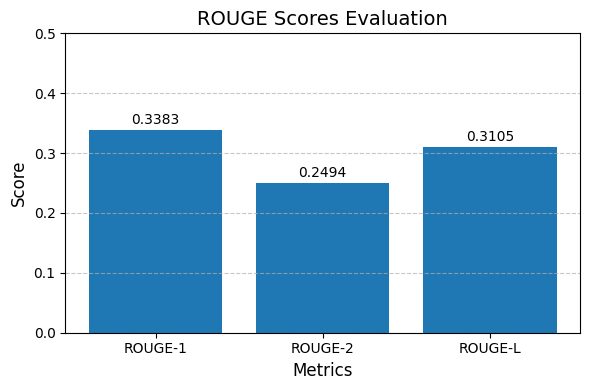

In [29]:
# VISUALISASI HASIL EVALUASI

import matplotlib.pyplot as plt

# Data skor ROUGE
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores = [0.3383, 0.2494, 0.3105]

# Membuat bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(metrics, scores)

# Menambahkan label nilai di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom')

# Judul dan label sumbu
plt.title('ROUGE Scores Evaluation', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metrics', fontsize=12)
plt.ylim(0, 0.5)  # Skala 0-0.5 karena skor maksimal 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tampilkan plot
plt.tight_layout()
plt.show()

In [30]:
plt.savefig('rouge_scores.png', dpi=150)

<Figure size 640x480 with 0 Axes>

In [31]:
# ============================================
# 13. SIMPAN MODEL
# ============================================
model.save_pretrained(f"{OUTPUT_DIR}/final_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/final_model")

print(f"\n✅ Model saved to {OUTPUT_DIR}/final_model")

# ============================================
# 13. SIMPAN HASIL ROUGE KE FILE
# ============================================
if valid_pairs:
    with open(f"{OUTPUT_DIR}/rouge_scores.txt", 'w') as f:
        f.write(f"ROUGE-1: {rouge_results['rouge1']:.4f}\n")
        f.write(f"ROUGE-2: {rouge_results['rouge2']:.4f}\n")
        f.write(f"ROUGE-L: {rouge_results['rougeL']:.4f}\n")

    print(f"\n✅ ROUGE scores saved to {OUTPUT_DIR}/rouge_scores.txt")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved to ./indobert-extractive-summarizer/final_model

✅ ROUGE scores saved to ./indobert-extractive-summarizer/rouge_scores.txt
